In [19]:
from google.colab import files
uploaded = files.upload()


Saving data.csv.csv to data.csv (1).csv


In [20]:
import pandas as pd

df = pd.read_csv('data.csv.csv')
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [21]:
df = df.dropna()


In [22]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [23]:
df['Last Interaction'] = pd.to_datetime(df['Last Interaction'])

In [24]:
today = df['Last Interaction'].max()

df['Recency'] = (today - df['Last Interaction']).dt.days

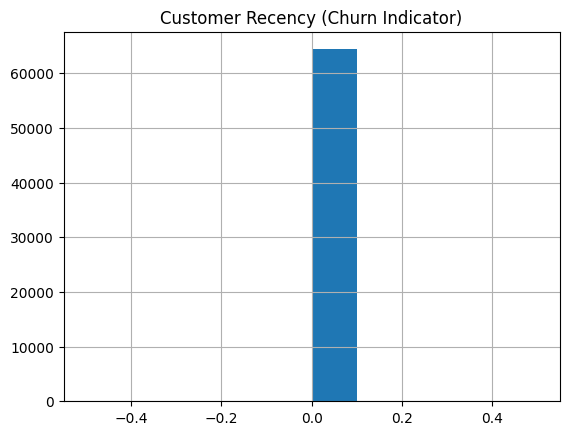

In [25]:
import matplotlib.pyplot as plt

df['Recency'].hist()
plt.title("Customer Recency (Churn Indicator)")
plt.show()

<Axes: >

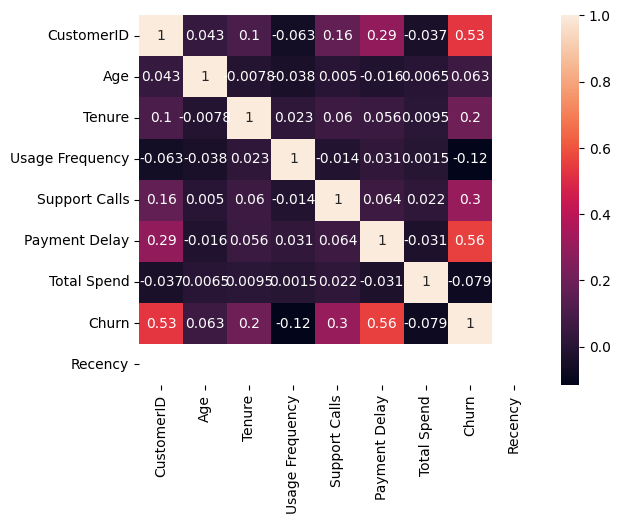

In [26]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Convert categorical
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

# Features & target
X = df[['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
        'Payment Delay', 'Total Spend', 'Recency']]

y = df['Churn']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Accuracy
print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 0.810252427184466


<Axes: >

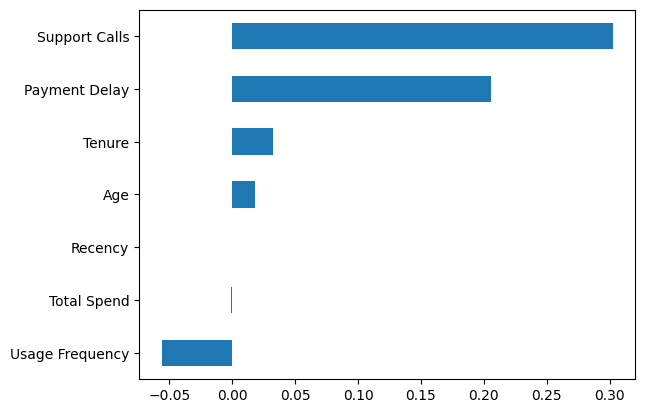

In [28]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh')

Project Summary:

Customers with high recency are more likely to churn
Higher usage frequency improves retention
More support calls may indicate dissatisfaction
Customers with longer tenure are more loyal
The model predicts churn using customer behavior patterns